## Practica 05: Generacion de Dataset de Pacientes con indicadores para el calculo de riesgo de Infarto Cardiaco en Puebla

### Unidad 2. Preparacion de los Datos
**Nombre del Estudiante:** Jenny \
**Matricula:** 230317 \
**Materia:** Extraccion de Conocimiento de Bases de Datos \
**Docente:** M.T.I. Marco A. Ramirez Hernandez

El estudiante genera de manera individual un dataset clinico simulado con informacion de 5,000 pacientes generales del estado de Puebla. El proposito es construir una base de datos que servira como punto de partida para practicas posteriores relacionadas con la clasificacion de pacientes, visualizacion de datos y aplicacion de algoritmos de analisis supervisado.

Los datos son ficticios y tienen unicamente fines academicos, por lo que no se utilizaron datos reales de pacientes ni informacion personal sensible.

### 1. Carga del dataset e importacion de librerias
Se importan las librerias necesarias y se carga el dataset generado.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
df = pd.read_csv("dataset_riesgo_infarto_puebla.csv")

### 2. Verificar las dimensiones del dataset
Se verifica el total de registros y el numero de columnas del dataset utilizado.

In [2]:
df.shape
print(f"Registros: {df.shape[0]}, Columnas: {df.shape[1]}")

Registros: 5000, Columnas: 33


### 3. Validar los nombres de las columnas
Se validan los nombres de columnas verificando espacios y mayusculas.

In [3]:
df.columns.tolist()

for col in df.columns:
    if " " in col or col != col.lower():
        print("Nombre invalido:", col)

### 4. Verificar los tipos de datos
Se revisa la integracion de los tipos de datos, convirtiendo fechas y forzando categorias.

In [4]:
df.dtypes
df.info()

df["fecha_registro"] = pd.to_datetime(df["fecha_registro"])

cat_cols = ["sexo", "municipio", "zona", "nivel_socioeconomico", "escolaridad", "ocupacion",
            "seguridad_social", "imc_categoria", "actividad_fisica", "tabaquismo",
            "consumo_alcohol", "dieta_calidad", "riesgo_cardiovascular"]
df[cat_cols] = df[cat_cols].astype("category")

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 33 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id_paciente                        5000 non-null   str    
 1   fecha_registro                     5000 non-null   str    
 2   edad                               5000 non-null   int64  
 3   sexo                               5000 non-null   str    
 4   municipio                          5000 non-null   str    
 5   zona                               5000 non-null   str    
 6   nivel_socioeconomico               5000 non-null   str    
 7   escolaridad                        5000 non-null   str    
 8   ocupacion                          5000 non-null   str    
 9   seguridad_social                   5000 non-null   str    
 10  peso_kg                            5000 non-null   float64
 11  estatura_cm                        5000 non-null   float64
 12  imc

### 5. Buscar valores nulos
Se buscan valores nulos en el dataset, mostrando las columnas afectadas y su porcentaje.

In [5]:
nulos = df.isnull().sum()
nulos_pct = (df.isnull().mean() * 100).round(2)

resumen_nulos = pd.DataFrame({"nulos": nulos, "porcentaje": nulos_pct})
resumen_nulos = resumen_nulos[resumen_nulos["nulos"] > 0]

if resumen_nulos.empty:
    print("No se encontraron valores nulos en el dataset.")
else:
    print("Columnas con valores nulos:")
    print(resumen_nulos)

Columnas con valores nulos:
                       nulos  porcentaje
saturacion_oxigeno       305        6.10
colesterol_total_mgdl    243        4.86
hdl_mgdl                 251        5.02
ldl_mgdl                 315        6.30
trigliceridos_mgdl       215        4.30


### 6. Buscar registros duplicados
Se buscan registros duplicados por fila completa y por identificador de paciente.

In [6]:
df.duplicated().sum()
df["id_paciente"].duplicated().sum()
df[df.duplicated(subset="id_paciente", keep=False)]

,id_paciente,fecha_registro,edad,sexo,municipio,zona,nivel_socioeconomico,escolaridad,ocupacion,seguridad_social,...,actividad_fisica,tabaquismo,consumo_alcohol,dieta_calidad,horas_sueno,estres_percibido_1_10,antecedentes_familiares_cardiacos,diabetes_diagnosticada,hipertension_diagnosticada,riesgo_cardiovascular


### 7. Validar rangos clinicos
Se validan los rangos clinicos verificando que ningun valor este fuera del limite esperado.

In [7]:
rangos = {
    "edad": (18, 95),
    "peso_kg": (35, 180),
    "estatura_cm": (140, 200),
    "imc": (15, 55),
    "presion_sistolica": (85, 220),
    "presion_diastolica": (55, 130),
    "frecuencia_cardiaca": (45, 140),
    "saturacion_oxigeno": (88, 100),
    "glucosa_ayunas_mgdl": (60, 300),
    "colesterol_total_mgdl": (100, 350),
    "hdl_mgdl": (20, 100),
    "ldl_mgdl": (40, 250),
    "trigliceridos_mgdl": (40, 500),
}

for col, (lo, hi) in rangos.items():
    fuera = df[(df[col] < lo) | (df[col] > hi)]
    print(f"{col}: {len(fuera)} valores fuera de rango [{lo}, {hi}]")

edad: 0 valores fuera de rango [18, 95]
peso_kg: 0 valores fuera de rango [35, 180]
estatura_cm: 0 valores fuera de rango [140, 200]
imc: 0 valores fuera de rango [15, 55]
presion_sistolica: 0 valores fuera de rango [85, 220]
presion_diastolica: 0 valores fuera de rango [55, 130]
frecuencia_cardiaca: 0 valores fuera de rango [45, 140]
saturacion_oxigeno: 0 valores fuera de rango [88, 100]
glucosa_ayunas_mgdl: 0 valores fuera de rango [60, 300]
colesterol_total_mgdl: 0 valores fuera de rango [100, 350]
hdl_mgdl: 0 valores fuera de rango [20, 100]
ldl_mgdl: 0 valores fuera de rango [40, 250]
trigliceridos_mgdl: 0 valores fuera de rango [40, 500]


### 8. Validar datos geograficos
Se valida que los municipios registrados correspondan al estado de Puebla.

In [8]:
municipios_validos = [
    "Puebla", "Tehuacan", "San Martin Texmelucan", "Atlixco", "San Pedro Cholula",
    "San Andres Cholula", "Amozoc", "Huauchinango", "Zacatlan", "Teziutlan",
    "Izucar de Matamoros", "Cuetzalan", "Chignahuapan", "Acatlan", "Tepeaca",
    "Xicotepec de Juarez", "Zacapoaxtla"
]
df["municipio"].unique()
df[~df["municipio"].isin(municipios_validos)]

df["zona"].unique()

['urbana', 'rural']
Categories (2, str): ['rural', 'urbana']

### 9. Realizar limpieza basica de datos
Se imputan los valores nulos de laboratorio con la mediana, se eliminan duplicados y registros fuera de rango.

In [9]:
lab_cols = ["colesterol_total_mgdl", "hdl_mgdl", "ldl_mgdl", "trigliceridos_mgdl", "saturacion_oxigeno"]
for col in lab_cols:
    df[col] = df[col].fillna(df[col].median())

# eliminar duplicados
df = df.drop_duplicates()
df = df.drop_duplicates(subset="id_paciente")

# eliminar registros fuera de rango
for col, (lo, hi) in rangos.items():
    df = df[(df[col] >= lo) & (df[col] <= hi)]

df = df.reset_index(drop=True)
df.shape  # verificar

(5000, 33)

### 10. Realizar analisis estadistico inicial
Primer analisis estadistico descriptivo: promedio, mediana, minimo, maximo y desviacion estandar.

In [10]:
df.describe().T

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

resumen = pd.DataFrame({
    "media": df[num_cols].mean(),
    "mediana": df[num_cols].median(),
    "min": df[num_cols].min(),
    "max": df[num_cols].max(),
    "desv_std": df[num_cols].std(),
})
print(resumen.round(2))

                                    media  mediana    min    max  desv_std
edad                                56.38     56.0   18.0   95.0     22.24
peso_kg                             73.79     72.8   35.0  132.5     15.99
estatura_cm                        163.20    163.1  140.0  191.8      9.07
imc                                 27.61     27.7   15.0   48.9      5.09
presion_sistolica                  116.12    116.0   85.0  164.0     14.50
presion_diastolica                  70.50     70.0   55.0  101.0      8.12
frecuencia_cardiaca                 76.66     77.0   45.0  118.0     11.17
saturacion_oxigeno                  96.99     97.0   91.3  100.0      1.46
glucosa_ayunas_mgdl                107.15    101.0   60.0  194.0     24.94
colesterol_total_mgdl              203.63    203.9  100.0  330.4     33.99
hdl_mgdl                            46.09     46.2   20.0   84.8     11.68
ldl_mgdl                           127.82    127.8   40.0  250.0     38.41
trigliceridos_mgdl       

### 11. Generar visualizaciones EDA basicas

#### 11.1 Histogramas de variables clinicas clave
Se generan histogramas con curva de densidad para visualizar la distribucion de las variables clinicas principales.

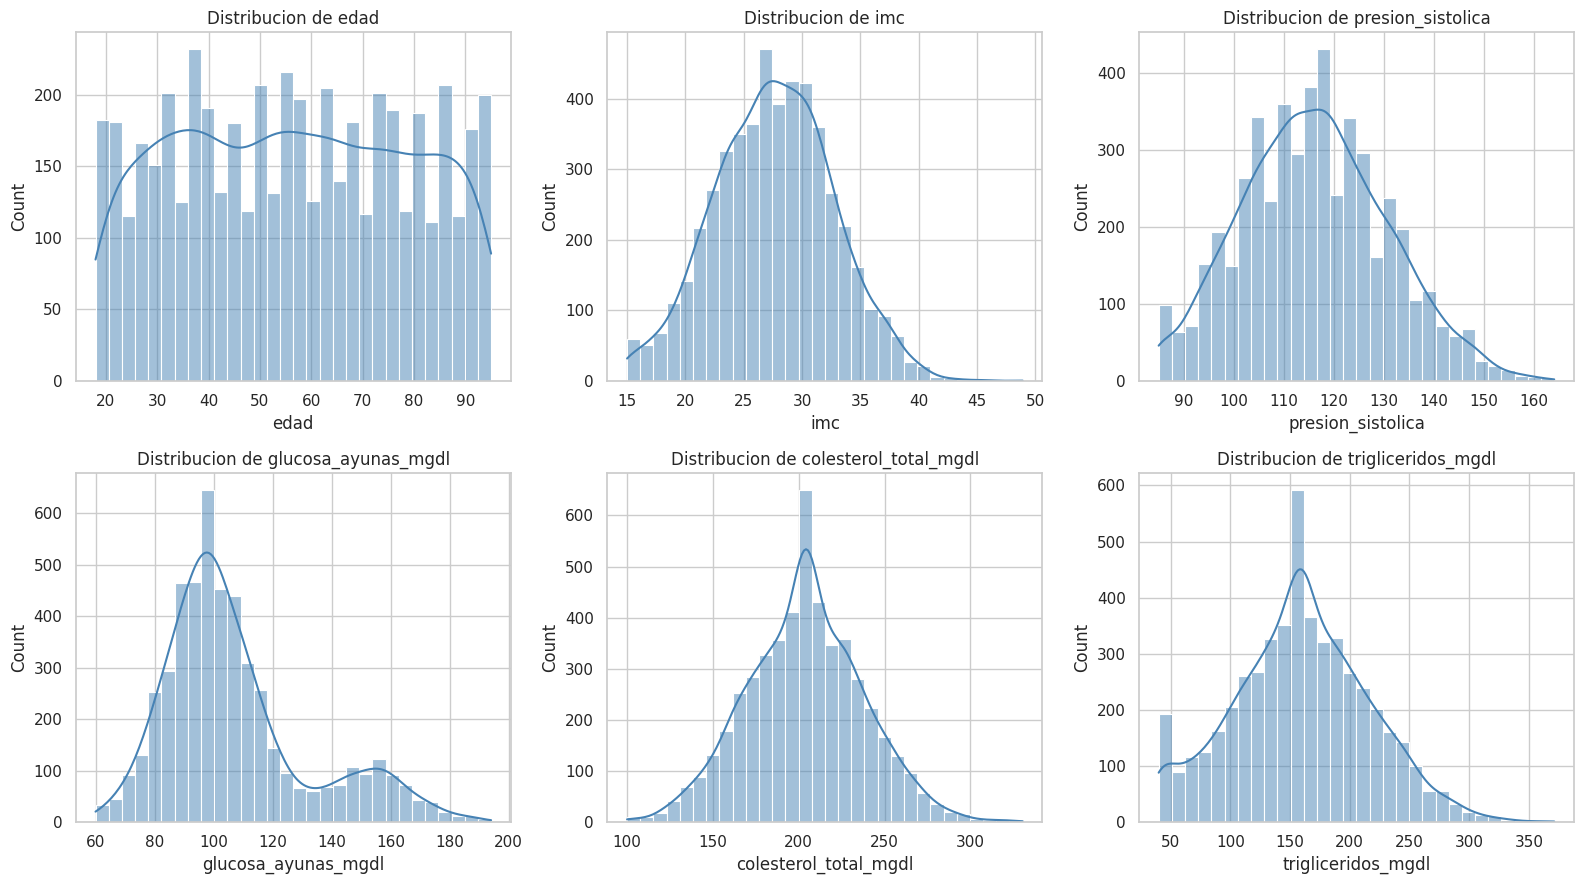

In [11]:
vars_hist = ["edad", "imc", "presion_sistolica", "glucosa_ayunas_mgdl",
             "colesterol_total_mgdl", "trigliceridos_mgdl"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), vars_hist):
    sns.histplot(df[col], kde=True, ax=ax, bins=30, color="steelblue")
    ax.set_title(f"Distribucion de {col}")
plt.tight_layout()
plt.show()

#### 11.2 Grafica de barras para variables categoricas
Se generan graficos de barras para mostrar la distribucion de variables categoricas clave.

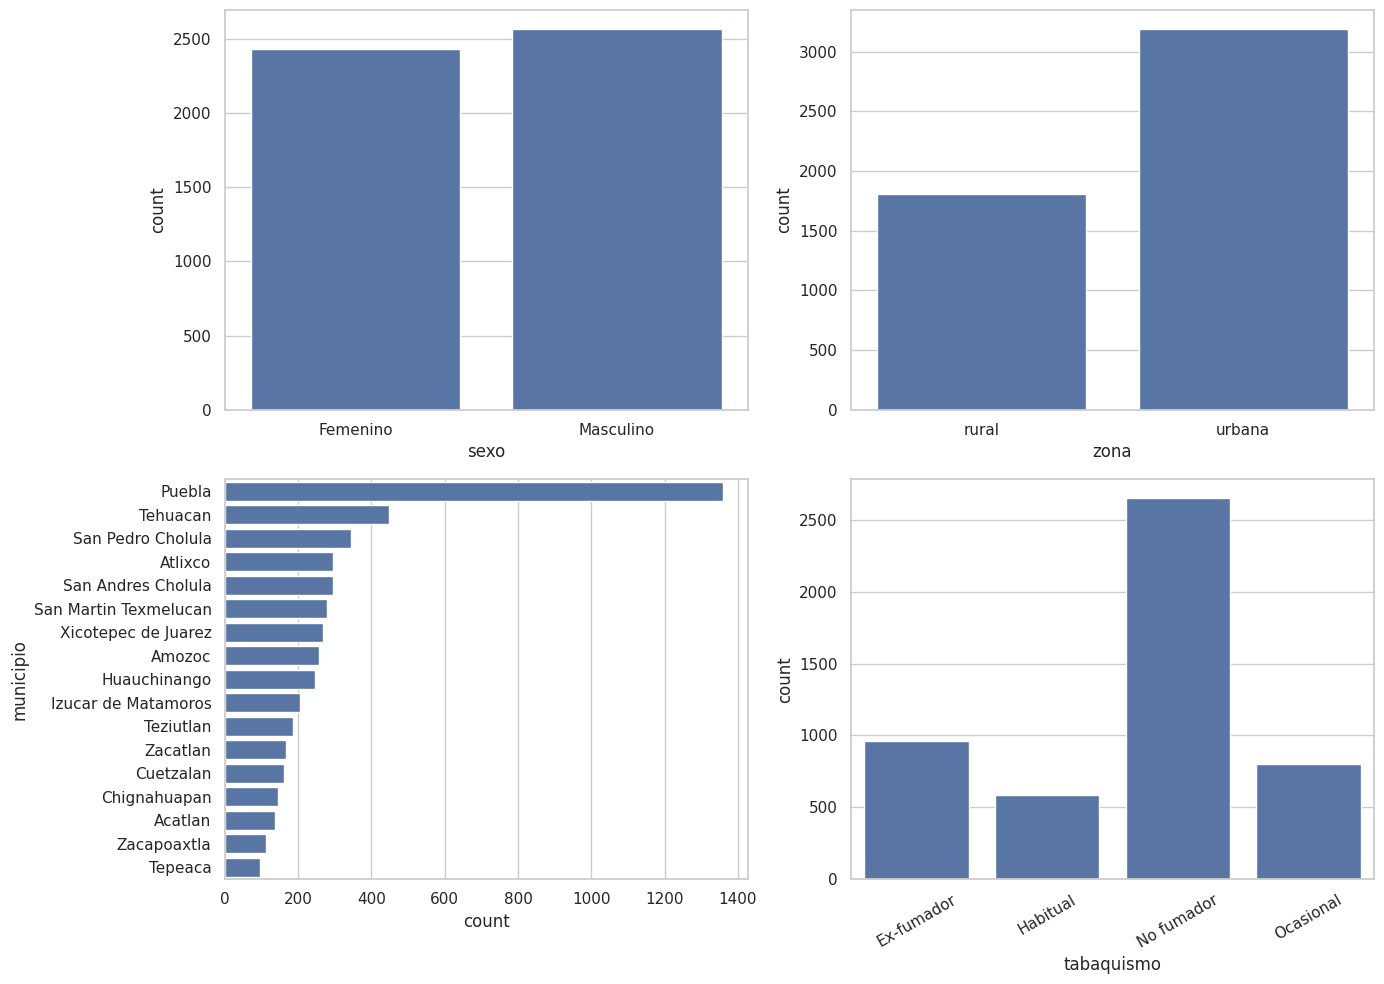

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(data=df, x="sexo", ax=axes[0,0])
sns.countplot(data=df, x="zona", ax=axes[0,1])
sns.countplot(data=df, y="municipio", order=df["municipio"].value_counts().index, ax=axes[1,0])
sns.countplot(data=df, x="tabaquismo", ax=axes[1,1])
axes[1,1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

#### 11.3 Diagrama de dispersion para relaciones clinicas tipicas
Se generan tres graficos de dispersion para observar relaciones clinicas relevantes coloreadas por nivel de riesgo.

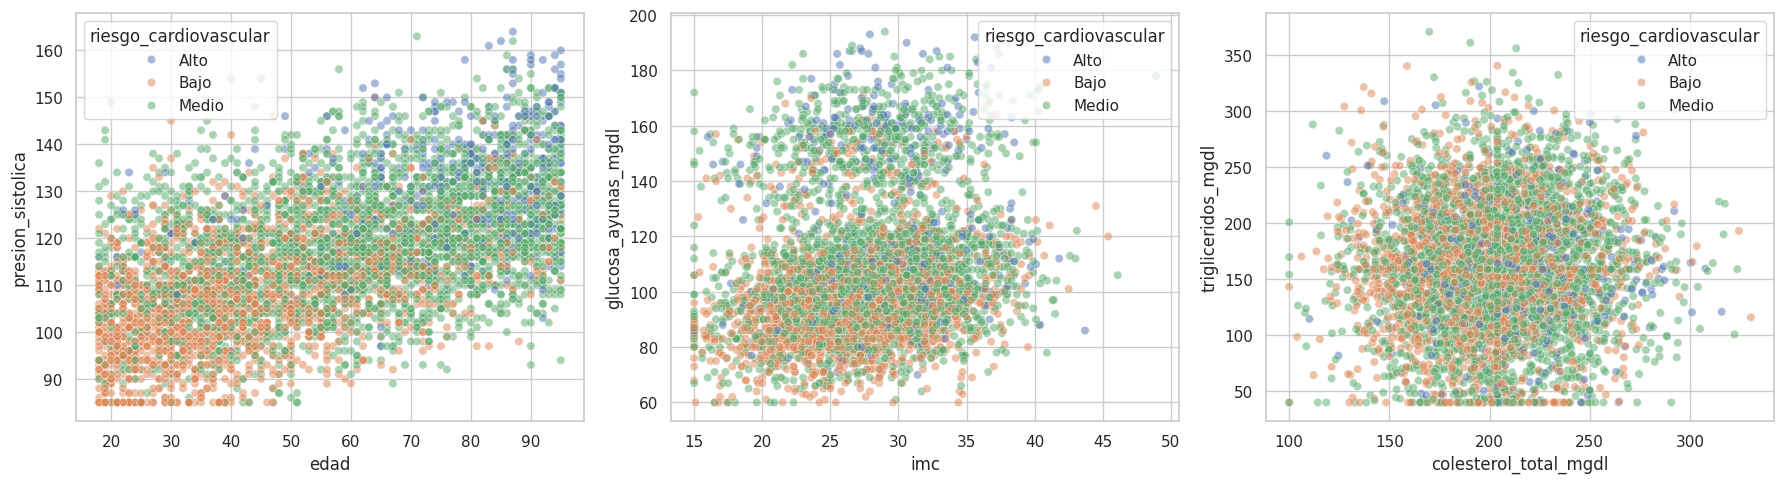

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=df, x="edad", y="presion_sistolica", hue="riesgo_cardiovascular", ax=axes[0], alpha=0.5)
sns.scatterplot(data=df, x="imc", y="glucosa_ayunas_mgdl", hue="riesgo_cardiovascular", ax=axes[1], alpha=0.5)
sns.scatterplot(data=df, x="colesterol_total_mgdl", y="trigliceridos_mgdl", hue="riesgo_cardiovascular", ax=axes[2], alpha=0.5)
plt.tight_layout()
plt.show()

#### 11.4 Matriz de correlacion
Se calcula la matriz de correlacion de las variables numericas y se representa mediante un mapa de calor.

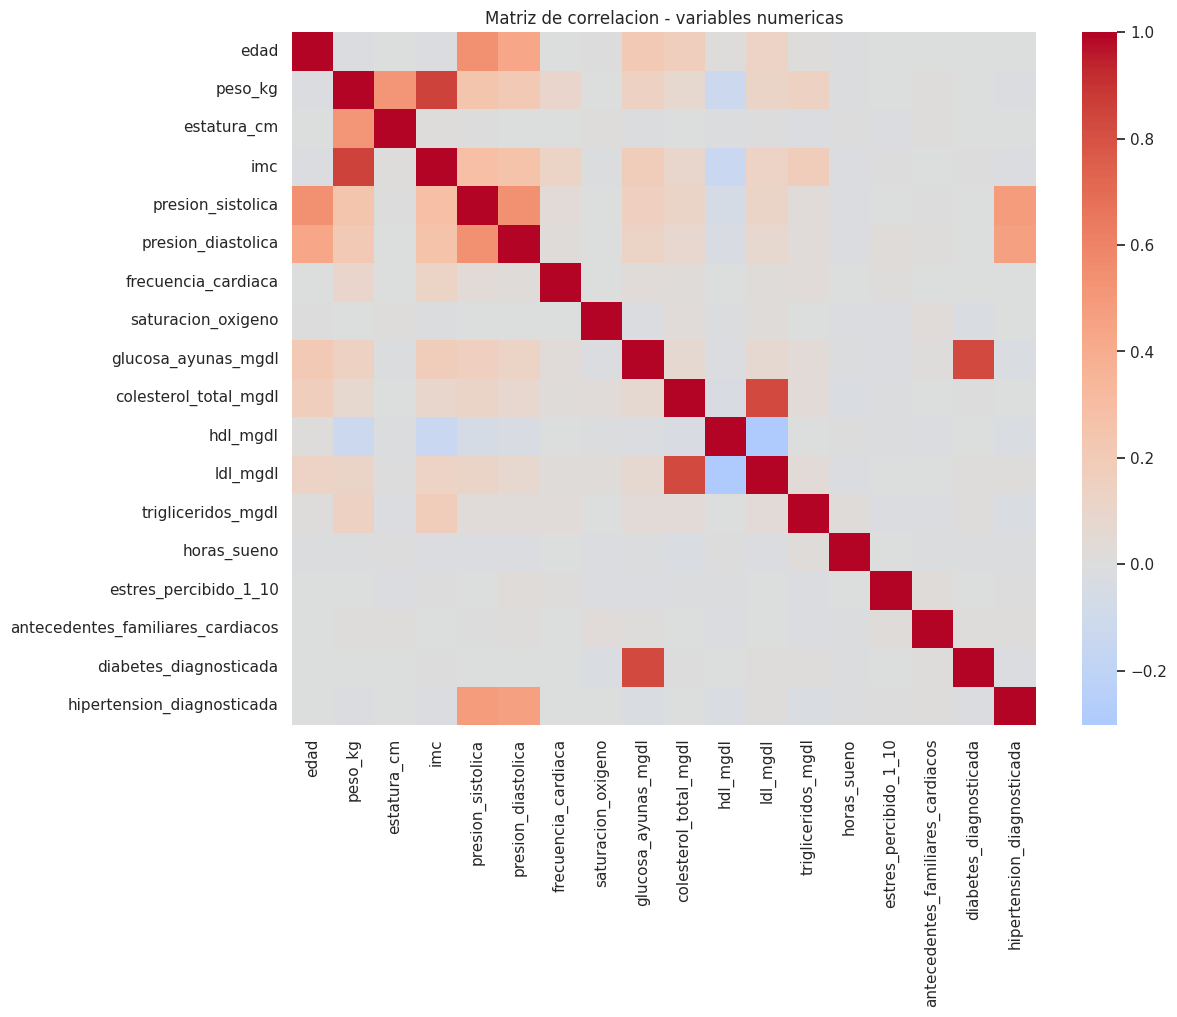

In [14]:
plt.figure(figsize=(12, 9))
sns.heatmap(df[num_cols].corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Matriz de correlacion - variables numericas")
plt.show()

#### 12. Analisis de la distribucion del riesgo cardiovascular
Se genera un grafico de barras que muestra la distribucion de pacientes por nivel de riesgo cardiovascular.

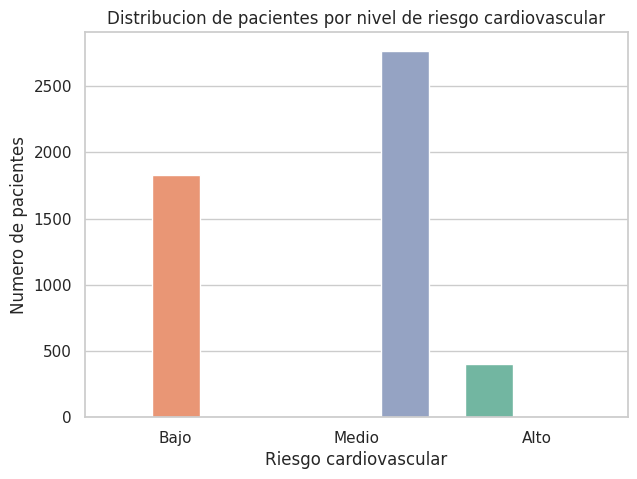

In [15]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="riesgo_cardiovascular", order=["Bajo", "Medio", "Alto"],
              hue="riesgo_cardiovascular", palette="Set2", legend=False)
plt.title("Distribucion de pacientes por nivel de riesgo cardiovascular")
plt.xlabel("Riesgo cardiovascular")
plt.ylabel("Numero de pacientes")
plt.show()